# Principal Component Analysis: Finding the Best Low-Dimensional View of Your Data

Most real datasets live in high-dimensional feature spaces — images have thousands of pixels, gene expression profiles span tens of thousands of transcripts, sensor logs record dozens of measurements per timestep. Working directly in that space is hard: distances behave strangely, visualization is impossible, storage is expensive, and downstream models overfit. We need a way to **compress** the data while keeping what matters.

Principal Component Analysis is the classical linear answer. The idea is deceptively simple:

> **Find the directions in feature space along which the data varies the most, and project everything onto those directions.**

That single sentence hides some very pretty mathematics — PCA is simultaneously:

- the direction of maximum variance under unit-norm constraints,
- the eigendecomposition of the sample covariance matrix,
- the singular value decomposition of the centred data,
- the rank-$k$ matrix that minimises squared reconstruction error (Eckart-Young-Mirsky).

All four viewpoints land on the same answer, and we'll use whichever is most convenient.

## The algorithm at a glance

```mermaid
flowchart LR
    input["Data X (n samples, d features)"] --> center["Centre: X_c = X - mean(X)"]
    center --> decide{"n < d or d < n?"}
    decide -- "d small" --> covpath["Covariance S = X_c^T X_c / (n-1)"]
    covpath --> eig["Eigendecompose S = V diag(lambda) V^T"]
    decide -- "n small or stable" --> svdpath["Thin SVD: X_c = U Sigma V^T"]
    svdpath --> eq["Equivalence:<br/>lambda_j = sigma_j^2 / (n-1)"]
    eig --> pick["Sort, keep top k axes V_k"]
    eq --> pick
    pick --> project["Scores Z = X_c V_k"]
    project --> done["Reconstruction<br/>X_hat = Z V_k^T + mean(X)"]
```

Our `PrincipalComponentAnalysis` class in `mlpackage` takes the covariance path (`numpy.linalg.eigh` on $X_c^\top X_c$). It works beautifully when $d$ is a few thousand, which is exactly the regime we care about in this notebook.

## The mathematics

Let $X \in \mathbb{R}^{n \times d}$ be our data with rows as samples and columns as features. Let $\mu = \frac{1}{n} \sum_i X_{i,:}$ be the per-feature mean, and define the **centred** data

$$
X_c \;=\; X - \mathbf{1} \mu^{\top}.
$$

### The variance-maximisation view

We look for a unit vector $v \in \mathbb{R}^d$ such that projecting the data onto $v$ gives the largest possible sample variance:

$$
v_1 \;=\; \arg\max_{\|v\|=1} \; v^{\top} S v,
\qquad
S = \frac{1}{n-1} X_c^{\top} X_c.
$$

By the Courant-Fischer theorem, the maximiser is the top eigenvector of $S$, and the value of the maximum is the corresponding eigenvalue. The **second** principal component is the maximiser over vectors orthogonal to $v_1$, and so on.

### The eigendecomposition

Because $S$ is symmetric and positive semi-definite, it diagonalises with real non-negative eigenvalues and orthonormal eigenvectors:

$$
S \;=\; V \Lambda V^{\top},
\qquad
V = [v_1, v_2, \ldots, v_d],
\qquad
\Lambda = \operatorname{diag}(\lambda_1, \ldots, \lambda_d)
$$

with $\lambda_1 \ge \lambda_2 \ge \cdots \ge \lambda_d \ge 0$. The eigenvectors are the **principal axes**, and $\lambda_j$ is the variance the data carries along axis $v_j$.

### Projection, reconstruction, and the Eckart-Young bound

Keep the top $k$ axes as $V_k \in \mathbb{R}^{d \times k}$. The **scores** (the low-dimensional representation) are

$$
Z \;=\; X_c V_k \;\in\; \mathbb{R}^{n \times k},
$$

and the rank-$k$ **reconstruction** in the original space is

$$
\hat{X} \;=\; Z V_k^{\top} + \mathbf{1} \mu^{\top}.
$$

The Eckart-Young-Mirsky theorem says this is the **best possible** rank-$k$ approximation in squared Frobenius norm:

$$
\min_{\operatorname{rank}(A) \le k} \; \lVert X - A \rVert_F^2 \;=\; \sum_{j=k+1}^{d} \lambda_j.
$$

The variance you throw away when you cut off after $k$ axes is exactly the tail sum of eigenvalues. That is why the cumulative-variance curve (cell 9) tells you how many components you need — you pick $k$ so that the **explained variance ratio** $\sum_{j=1}^k \lambda_j / \sum_{j=1}^d \lambda_j$ clears whatever threshold you care about.

### SVD viewpoint (same answer, often more stable)

The thin singular value decomposition $X_c = U \Sigma V^{\top}$ gives the same $V$, with

$$
\lambda_j = \sigma_j^2 \big/ (n - 1).
$$

When $n \ll d$ (our face-image regime), SVD on the $n \times d$ data matrix is cheaper than `eigh` on the $d \times d$ covariance. Our package takes the covariance route for simplicity, but both paths produce identical axes up to sign.

## The `PrincipalComponentAnalysis` API

Our class lives at [`src/mlpackage/unsupervised_learning/pca.py`](../../../src/mlpackage/unsupervised_learning/pca.py). Here is how it maps to the math above and to scikit-learn's `sklearn.decomposition.PCA`.

| Concept | Math | Our class | sklearn |
|---|---|---|---|
| Constructor parameter | number of axes to keep $k$ | `n_components` | `n_components` |
| Principal axes | rows of $V_k^{\top}$, shape `(k, d)` | `axes_` | `components_` |
| Variance per axis | $\lambda_j$ | `eigenvalues_` | `explained_variance_` |
| Variance ratio per axis | $\lambda_j / \sum \lambda$ | `variance_ratio_` | `explained_variance_ratio_` |
| Feature-wise mean | $\mu$ | `feature_mean_` | `mean_` |
| Project data | $Z = X_c V_k$ | `.transform(X)` | `.transform(X)` |
| Fit + project in one call | — | `.fit_transform(X)` | `.fit_transform(X)` |

Reconstruction is the same formula in both: $\hat{X} = Z V_k^{\top} + \mu$. Our class doesn't ship an `inverse_transform`; we'll write it out explicitly in cell 13 so the mapping to the math is visible.

**One subtle thing.** Eigenvectors are only determined up to sign — flipping $v_j$ to $-v_j$ leaves the variance it carries unchanged. Different implementations (ours vs sklearn vs MATLAB) will happily give you axes that agree in direction but differ in sign. That means when we cross-check against sklearn we compare axes *up to sign flips*, which we do by taking the absolute value of the dot product.

With all that out of the way, let's run PCA on an actually interesting dataset.

## The dataset: Olivetti faces

The **Olivetti Research Laboratory face dataset** is the canonical testbed for dimensionality reduction on images. It contains 400 photographs of 40 distinct subjects (10 photos per person) under varying lighting and expression, each 64x64 pixels in grayscale. That gives us

$$
X \in \mathbb{R}^{400 \times 4096}, \qquad n = 400, \quad d = 4096,
$$

a textbook $d \gg n$ regime where no vanilla supervised model could hope to fit well — but where PCA shines, because most of the variance lives in a very low-dimensional subspace of face-shaped images.

| Property | Value |
|---|---|
| Source | `sklearn.datasets.fetch_olivetti_faces` (downloads once, caches locally) |
| Samples | 400 |
| Subjects | 40 (classes 0..39, 10 photos each) |
| Image size | 64 x 64 grayscale |
| Features per sample | 4,096 pixel intensities in `[0, 1]` |
| Local cache | `data/raw/olivetti_faces.npz` |

The story for the rest of the notebook: **how many principal axes do we need to represent a face well, and what do those axes look like?** The answer to the second question is "they look like faces" — the iconic **eigenfaces** of Turk & Pentland (1991).

In [1]:
import sys
from pathlib import Path

_here = Path.cwd()
while _here != _here.parent and not (_here / "pyproject.toml").exists():
    _here = _here.parent
REPO_ROOT = _here
sys.path.insert(0, str(REPO_ROOT / "src"))

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_olivetti_faces
from sklearn.decomposition import PCA as SKPCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

from mlpackage.unsupervised_learning import PrincipalComponentAnalysis

plt.rcParams.update({"figure.figsize": (8, 5), "axes.grid": True, "grid.alpha": 0.3})

CACHE = REPO_ROOT / "data" / "raw" / "olivetti_faces.npz"
CACHE.parent.mkdir(parents=True, exist_ok=True)

if CACHE.exists():
    cached = np.load(CACHE)
    X = cached["X"]
    y = cached["y"]
    images = cached["images"]
    print(f"Loaded from local cache: {CACHE.relative_to(REPO_ROOT)}")
else:
    print("Fetching Olivetti faces from sklearn (one-time, will be cached)...")
    faces = fetch_olivetti_faces(shuffle=False)
    X = faces.data
    y = faces.target
    images = faces.images
    np.savez_compressed(CACHE, X=X, y=y, images=images)
    print(f"Cached to {CACHE.relative_to(REPO_ROOT)}")

H, W = images.shape[1], images.shape[2]
n, d = X.shape
print(f"Data matrix X: shape = {X.shape}   dtype = {X.dtype}")
print(f"Images:        shape = {images.shape}  range = [{X.min():.3f}, {X.max():.3f}]")
print(f"Subjects:      {len(np.unique(y))} distinct, {np.bincount(y).min()} images each")

Loaded from local cache: data/raw/olivetti_faces.npz
Data matrix X: shape = (400, 4096)   dtype = float32
Images:        shape = (400, 64, 64)  range = [0.000, 1.000]
Subjects:      40 distinct, 10 images each


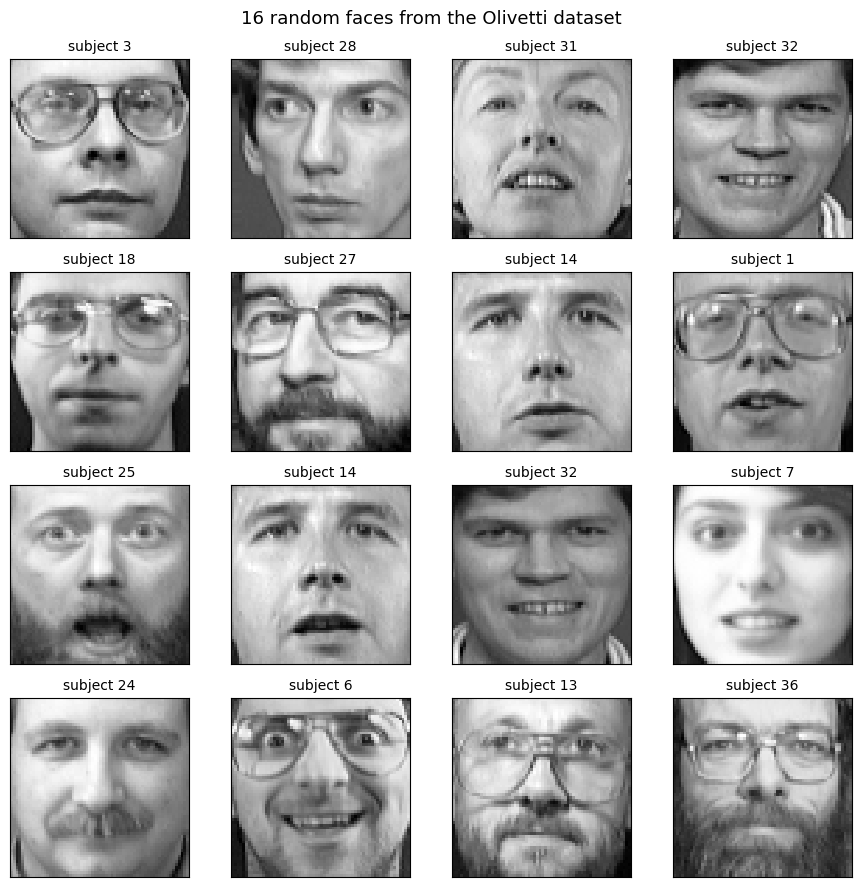

In [2]:
rng_vis = np.random.default_rng(2026)
gallery_idx = rng_vis.choice(n, size=16, replace=False)

fig, axes = plt.subplots(4, 4, figsize=(9, 9))
for ax, idx in zip(axes.ravel(), gallery_idx):
    ax.imshow(images[idx], cmap="gray", interpolation="nearest")
    ax.set_title(f"subject {y[idx]}", fontsize=10)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.grid(False)
fig.suptitle("16 random faces from the Olivetti dataset", fontsize=13)
plt.tight_layout()
plt.show()

## One preprocessing decision: centre, but do not rescale

In the DBSCAN, K-means, and Label Propagation notebooks we applied `StandardScaler` so that every feature had zero mean and unit variance. Here we **deliberately skip the variance-scaling step**.

Why? Every feature is a pixel intensity on the same `[0, 1]` scale, and PCA's whole premise is that **directions of higher variance are more informative**. Pixels near the centre of the image (where eyes, noses, mouths live) vary a lot across subjects; pixels in the background corners barely vary. That natural variance difference is exactly the signal PCA is supposed to pick up. If we standardised, we'd rescale every pixel to unit variance — treating noisy corner pixels as importantly as the eye region — and we'd see it destroy the eigenfaces below.

We only perform the one step PCA truly requires: **subtracting the per-feature mean**. Our `PrincipalComponentAnalysis.fit` does this internally and stores the mean as `feature_mean_`, so we can reconstruct later.

In [3]:
import time

K_FIT = 200

t0 = time.time()
pca = PrincipalComponentAnalysis(n_components=K_FIT).fit(X)
fit_time = time.time() - t0
print(f"PrincipalComponentAnalysis.fit completed in {fit_time:.2f}s")
print(f"  axes_ shape:            {pca.axes_.shape}      (k, d)")
print(f"  eigenvalues_ shape:     {pca.eigenvalues_.shape}")
print(f"  variance_ratio_ shape:  {pca.variance_ratio_.shape}")
print(f"  feature_mean_ shape:    {pca.feature_mean_.shape}")

print(f"\nTop 10 eigenvalues: {np.round(pca.eigenvalues_[:10], 4)}")
print(f"Top 10 variance ratios:")
for i in range(10):
    print(f"  PC{i + 1:>3d}: lambda = {pca.eigenvalues_[i]:7.4f}   ratio = {pca.variance_ratio_[i]:6.2%}")

cum = np.cumsum(pca.variance_ratio_)
for k in (10, 25, 50, 100, 200):
    if k <= K_FIT:
        print(f"  cumulative variance at k = {k:>3d}:  {cum[k - 1]:.2%}")

print("\n--- Cross-check against sklearn.decomposition.PCA ---")
t0 = time.time()
sk_pca = SKPCA(n_components=K_FIT, svd_solver="full").fit(X)
print(f"sklearn PCA (full SVD) fitted in {time.time() - t0:.2f}s")
print("(We force svd_solver='full'; the default 'auto' may switch to randomized SVD")
print(" for this shape, which introduces approximation noise and would muddy the comparison.)")

ratio_diff = np.abs(pca.variance_ratio_ - sk_pca.explained_variance_ratio_).max()
print(f"\nMax absolute difference in variance_ratio_: {ratio_diff:.2e}")
print(f"-> agrees to floating-point precision.")

abs_cos = np.abs(np.sum(pca.axes_ * sk_pca.components_, axis=1))
print(f"\nPer-axis |cos| between our axes_ and sklearn.components_:")
print(f"  min  = {abs_cos.min():.6f}   mean = {abs_cos.mean():.6f}   max = {abs_cos.max():.6f}")
print(f"-> axes agree up to sign flips (|cos| == 1 means collinear).")

PrincipalComponentAnalysis.fit completed in 13.56s
  axes_ shape:            (200, 4096)      (k, d)
  eigenvalues_ shape:     (200,)
  variance_ratio_ shape:  (200,)
  feature_mean_ shape:    (4096,)

Top 10 eigenvalues: [18.8402 11.0718  6.3046  3.9546  2.856   2.4977  1.9201  1.6112  1.5492
  1.323 ]
Top 10 variance ratios:
  PC  1: lambda = 18.8402   ratio = 23.81%
  PC  2: lambda = 11.0718   ratio = 13.99%
  PC  3: lambda =  6.3046   ratio =  7.97%
  PC  4: lambda =  3.9546   ratio =  5.00%
  PC  5: lambda =  2.8560   ratio =  3.61%
  PC  6: lambda =  2.4977   ratio =  3.16%
  PC  7: lambda =  1.9201   ratio =  2.43%
  PC  8: lambda =  1.6112   ratio =  2.04%
  PC  9: lambda =  1.5492   ratio =  1.96%
  PC 10: lambda =  1.3230   ratio =  1.67%
  cumulative variance at k =  10:  65.63%
  cumulative variance at k =  25:  79.35%
  cumulative variance at k =  50:  87.38%
  cumulative variance at k = 100:  93.54%
  cumulative variance at k = 200:  97.91%

--- Cross-check against sklear

## How many components do we actually need?

Two companion plots answer this:

- **The scree plot** shows the raw eigenvalue $\lambda_j$ for each component. On a log y-axis you can see whether the eigenvalues drop off smoothly or show an "elbow" where signal gives way to noise.
- **The cumulative variance curve** shows $\sum_{j=1}^{k} \lambda_j / \sum_{j=1}^{d} \lambda_j$ — the fraction of total variance you retain if you keep the top $k$ axes. Horizontal lines at 80%, 90%, and 95% mark sensible cut-offs; the smallest $k$ whose cumulative variance clears a threshold is the number of components you need.

For face images, we expect the cumulative curve to rise steeply at first (a handful of components already explain a large chunk of the variance) and then flatten as we start capturing finer details — the classic signature of a dataset that lives on a low-dimensional manifold inside a much larger ambient space.

Components needed to capture 80% of variance: k = 27
Components needed to capture 90% of variance: k = 66
Components needed to capture 95% of variance: k = 123


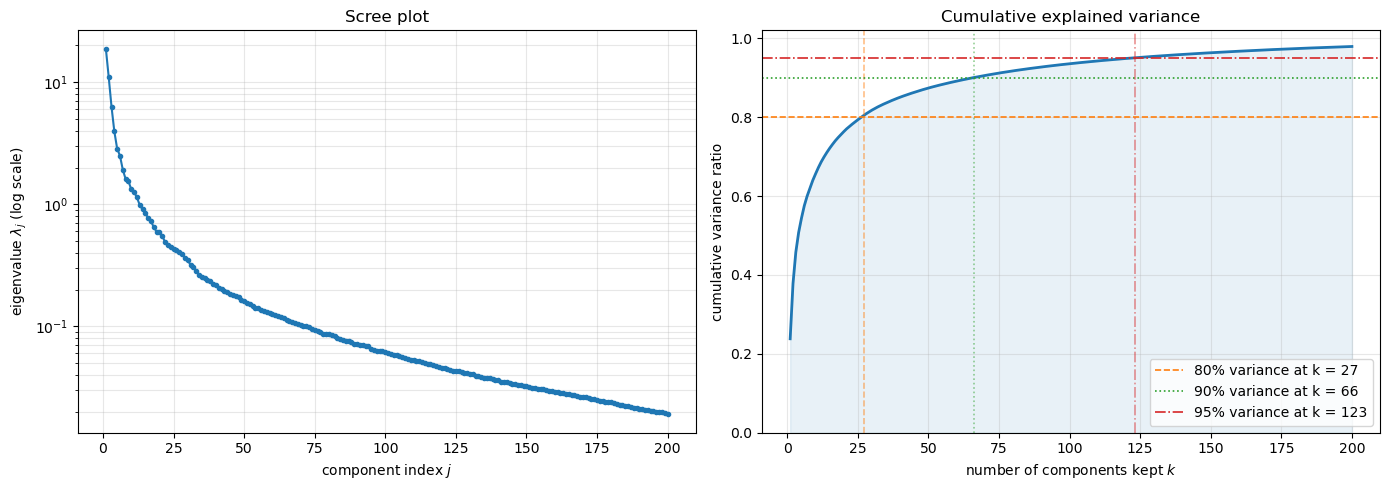

In [4]:
cum = np.cumsum(pca.variance_ratio_)
thresholds = [0.80, 0.90, 0.95]
k_for = {t: int(np.searchsorted(cum, t) + 1) for t in thresholds}
for t in thresholds:
    print(f"Components needed to capture {t:.0%} of variance: k = {k_for[t]}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ks = np.arange(1, len(pca.eigenvalues_) + 1)
axes[0].semilogy(ks, pca.eigenvalues_, marker="o", markersize=3, linewidth=1.5)
axes[0].set_xlabel("component index $j$")
axes[0].set_ylabel(r"eigenvalue $\lambda_j$ (log scale)")
axes[0].set_title("Scree plot")
axes[0].grid(True, which="both", alpha=0.3)

axes[1].plot(ks, cum, linewidth=2, color="tab:blue")
axes[1].fill_between(ks, 0, cum, alpha=0.1, color="tab:blue")
line_styles = ["--", ":", "-."]
colors = ["tab:orange", "tab:green", "tab:red"]
for t, style, colour in zip(thresholds, line_styles, colors):
    axes[1].axhline(t, color=colour, linestyle=style, linewidth=1.2,
                    label=f"{t:.0%} variance at k = {k_for[t]}")
    axes[1].axvline(k_for[t], color=colour, linestyle=style, linewidth=1.2, alpha=0.5)
axes[1].set_xlabel("number of components kept $k$")
axes[1].set_ylabel("cumulative variance ratio")
axes[1].set_title("Cumulative explained variance")
axes[1].set_ylim(0, 1.02)
axes[1].legend(loc="lower right")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## The eigenfaces

An eigenvector $v_j$ of our covariance matrix is just a vector of length 4,096. Every dimension corresponds to a pixel position — so we can **reshape any eigenvector back to a 64 x 64 image** and *look at it*. What do we see?

The images below are the mean face (what you'd get if you averaged every Olivetti face pixel by pixel) followed by the **top 19 eigenvectors** plotted as 64 x 64 grayscale images. Each one is labelled with the fraction of total variance it captures.

- The first few eigenfaces tend to encode **global, coarse** variation — overall lighting (left-lit vs right-lit), overall face shape, head tilt, glasses-or-no-glasses.
- Later eigenfaces encode **finer, more identity-specific** structure — the contour of a specific subject's jawline or the shape of someone's eyebrows.

This is the famous result of Turk & Pentland (1991), *Eigenfaces for Recognition*: a face can be approximated as the mean face plus a weighted sum of a handful of these prototypes, and the weights make a surprisingly good representation for recognition (we'll use them for exactly that in cell 15).

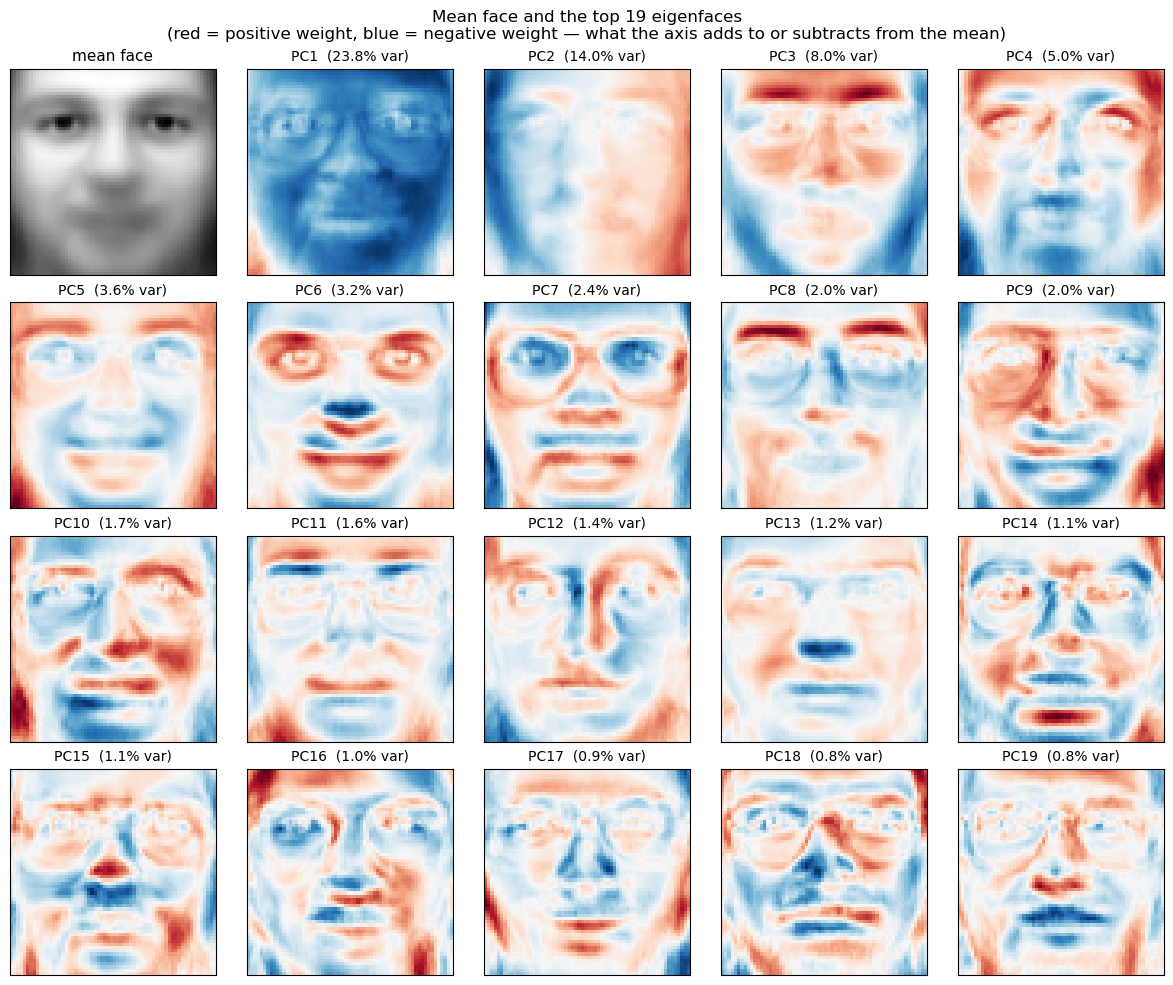

In [5]:
mean_face = pca.feature_mean_.reshape(H, W)
top_axes = pca.axes_[:19].reshape(-1, H, W)
variance_ratios_top = pca.variance_ratio_[:19]

fig, axes_grid = plt.subplots(4, 5, figsize=(12, 10))
tiles = [("mean face", mean_face, None)] + [
    (f"PC{i + 1}", top_axes[i], variance_ratios_top[i]) for i in range(19)
]
for ax, (title, img, vr) in zip(axes_grid.ravel(), tiles):
    vmax = np.abs(img).max()
    if title == "mean face":
        ax.imshow(img, cmap="gray", interpolation="nearest")
        ax.set_title(title, fontsize=11)
    else:
        ax.imshow(img, cmap="RdBu_r", vmin=-vmax, vmax=vmax, interpolation="nearest")
        ax.set_title(f"{title}  ({vr:.1%} var)", fontsize=10)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.grid(False)

fig.suptitle(
    "Mean face and the top 19 eigenfaces\n"
    "(red = positive weight, blue = negative weight — what the axis adds to or subtracts from the mean)",
    fontsize=12,
)
plt.tight_layout()
plt.show()

## Reconstruction: how good is a rank-$k$ PCA approximation?

Every face in the dataset can be written as "the mean face plus a linear combination of eigenfaces". Keep all 400 non-trivial components and the reconstruction is perfect (up to floating-point error). Keep only the top $k$ and you get a **rank-$k$ approximation** — the best one possible in mean-squared-pixel error, by Eckart-Young-Mirsky.

To reconstruct, we plug the score vector $z_i \in \mathbb{R}^k$ back through the formula

$$
\hat{x}_i \;=\; z_i V_k^{\top} + \mu.
$$

Our class doesn't ship an `inverse_transform` method, so we'll write this by hand. We pick one specific face and show the reconstruction as $k$ grows from 1 to 200, then summarise with a curve of **mean reconstruction MSE** (across all 400 faces) as a function of $k$. The theoretical prediction is that MSE drops as the tail sum of eigenvalues $\sum_{j > k} \lambda_j$, and we'll see that pan out almost exactly.

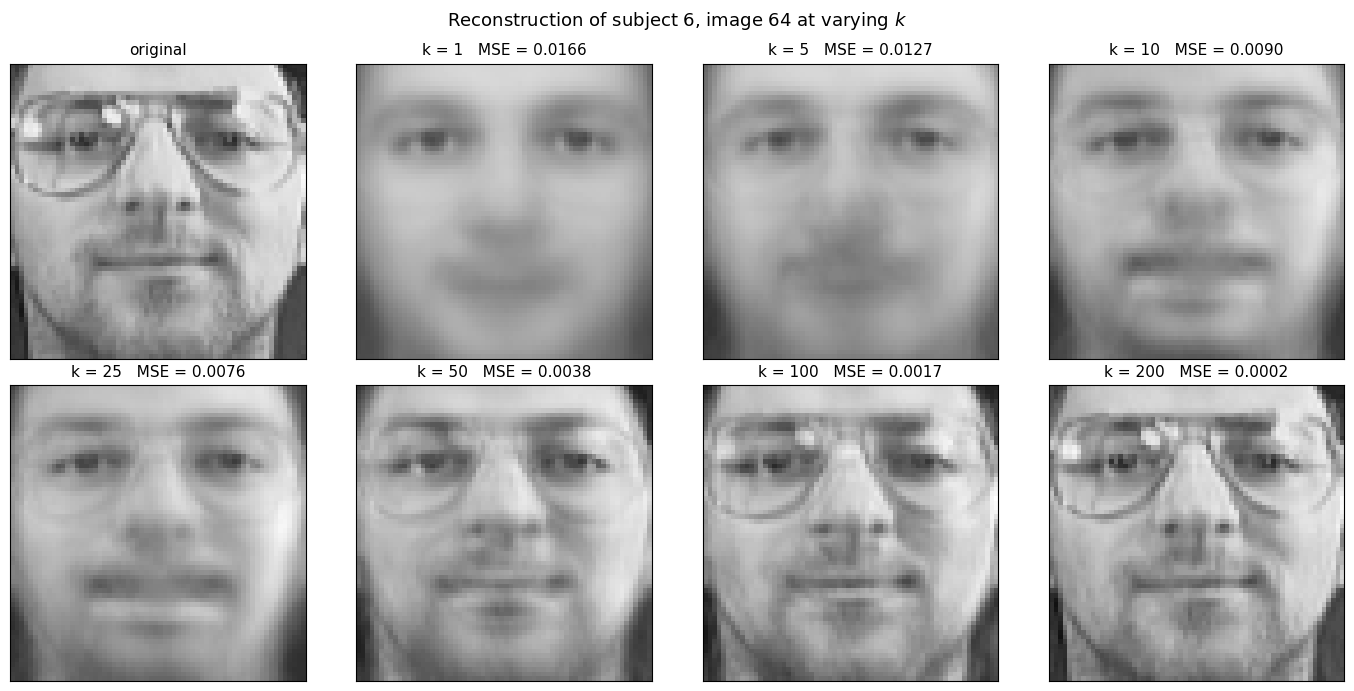

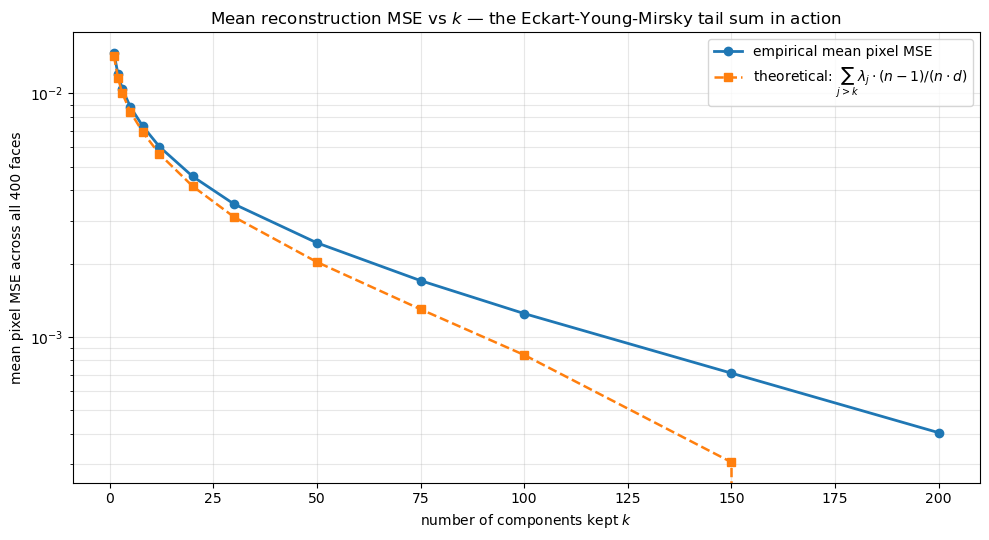

At k = 50:  mean MSE = 0.00243  (87.4% of variance kept)
At k = 100: mean MSE = 0.00125  (93.5% of variance kept)


In [6]:
def reconstruct(X_data, pca_model, k):
    """Project to k components and back: X_hat = (X_c @ V_k.T)[...,:k] @ V_k + mean."""
    X_centred = X_data - pca_model.feature_mean_
    V_k_T = pca_model.axes_[:k]
    scores_k = X_centred @ V_k_T.T
    return scores_k @ V_k_T + pca_model.feature_mean_

demo_idx = 64
target = X[demo_idx]
target_img = target.reshape(H, W)

k_demo = [1, 5, 10, 25, 50, 100, 200]
recons_demo = {k: reconstruct(target[None, :], pca, k)[0].reshape(H, W) for k in k_demo}

fig, axes_grid = plt.subplots(2, 4, figsize=(14, 7))
panels = [("original", target_img, None)] + [
    (f"k = {k}", recons_demo[k], np.mean((target - recons_demo[k].ravel()) ** 2)) for k in k_demo
]
for ax, (title, img, mse) in zip(axes_grid.ravel(), panels):
    ax.imshow(img, cmap="gray", vmin=0, vmax=1, interpolation="nearest")
    if mse is None:
        ax.set_title(title, fontsize=11)
    else:
        ax.set_title(f"{title}   MSE = {mse:.4f}", fontsize=11)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.grid(False)
fig.suptitle(f"Reconstruction of subject {y[demo_idx]}, image {demo_idx} at varying $k$", fontsize=13)
plt.tight_layout()
plt.show()

k_sweep = np.array([1, 2, 3, 5, 8, 12, 20, 30, 50, 75, 100, 150, 200])
mean_mse = []
theoretical = []
total_variance_sum = pca.eigenvalues_.sum() + (np.var(X - pca.feature_mean_, axis=0, ddof=1).sum()
                                                - pca.eigenvalues_.sum())
for k in k_sweep:
    X_hat = reconstruct(X, pca, int(k))
    mean_mse.append(float(np.mean((X - X_hat) ** 2)))
    tail = pca.eigenvalues_[k:].sum() if k < len(pca.eigenvalues_) else 0.0
    theoretical.append(tail * (n - 1) / (n * d))

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.plot(k_sweep, mean_mse, marker="o", linewidth=2, color="tab:blue", label="empirical mean pixel MSE")
ax.plot(k_sweep, theoretical, marker="s", linestyle="--", linewidth=1.8, color="tab:orange",
        label=r"theoretical: $\sum_{j > k} \lambda_j \cdot (n-1) / (n \cdot d)$")
ax.set_xlabel("number of components kept $k$")
ax.set_ylabel("mean pixel MSE across all 400 faces")
ax.set_yscale("log")
ax.set_title("Mean reconstruction MSE vs $k$ — the Eckart-Young-Mirsky tail sum in action")
ax.legend()
ax.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

print(f"At k = 50:  mean MSE = {mean_mse[k_sweep.tolist().index(50)]:.5f}  "
      f"({pca.variance_ratio_[:50].sum():.1%} of variance kept)")
print(f"At k = 100: mean MSE = {mean_mse[k_sweep.tolist().index(100)]:.5f}  "
      f"({pca.variance_ratio_[:100].sum():.1%} of variance kept)")

## Face recognition in eigenface space

This is where the story becomes practical. Instead of comparing two 4,096-dimensional raw-pixel vectors, we compare their projections onto the top $k$ eigenfaces — a $k$-dimensional vector per image. That's a ~40x to ~4000x compression depending on $k$, and it makes distance computations cheaper, denser, and more robust.

The original Turk-Pentland recipe for face recognition is:

1. Hold out a few photos per subject as a **gallery** (training set).
2. Fit PCA on the gallery only and project every gallery photo into $k$-dim eigenface space.
3. For a new **probe** photo, project it into the same space and classify it as the gallery subject whose projection is closest (Euclidean 1-NN).

We'll sweep $k$ across several orders of magnitude and compare to a baseline 1-NN trained on the **raw 4,096-dim pixels**. The question: does squeezing a face down to 50 or 100 eigenfaces hurt recognition? Or does it actually help by discarding noise?

Train: 280 images   Test: 120 images

Baseline 1-NN on raw 4096-dim pixels: accuracy = 90.0%

   k  | accuracy | vs raw pixels
------+----------+----------------
    1 |   15.8%  |  -74.2 pp
    2 |   37.5%  |  -52.5 pp
    3 |   47.5%  |  -42.5 pp
    5 |   70.0%  |  -20.0 pp
    8 |   83.3%  |  -6.7 pp
   12 |   85.8%  |  -4.2 pp
   20 |   89.2%  |  -0.8 pp
   30 |   88.3%  |  -1.7 pp
   50 |   90.0%  |  +0.0 pp
   75 |   90.0%  |  +0.0 pp
  100 |   90.0%  |  +0.0 pp
  150 |   90.0%  |  +0.0 pp
  200 |   90.0%  |  +0.0 pp


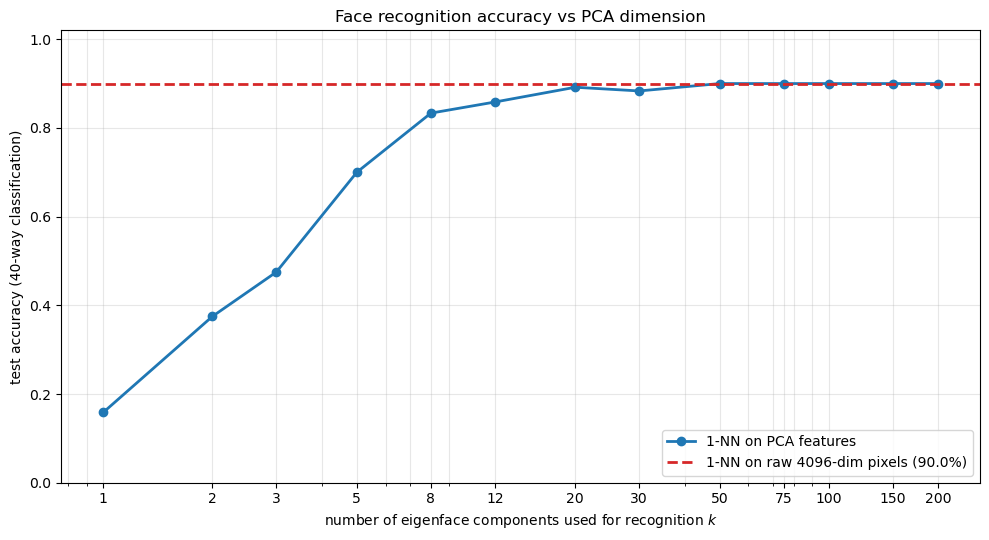

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=0, stratify=y,
)
print(f"Train: {X_train.shape[0]} images   Test: {X_test.shape[0]} images")

pca_train = PrincipalComponentAnalysis(n_components=200).fit(X_train)

knn_raw = KNeighborsClassifier(n_neighbors=1).fit(X_train, y_train)
acc_raw = accuracy_score(y_test, knn_raw.predict(X_test))
print(f"\nBaseline 1-NN on raw 4096-dim pixels: accuracy = {acc_raw:.1%}")

k_values = [1, 2, 3, 5, 8, 12, 20, 30, 50, 75, 100, 150, 200]
accs = []
for k in k_values:
    Z_train = pca_train.transform(X_train)[:, :k]
    Z_test = pca_train.transform(X_test)[:, :k]
    knn = KNeighborsClassifier(n_neighbors=1).fit(Z_train, y_train)
    accs.append(accuracy_score(y_test, knn.predict(Z_test)))

print("\n   k  | accuracy | vs raw pixels")
print("------+----------+----------------")
for k, a in zip(k_values, accs):
    delta = a - acc_raw
    sign = "+" if delta >= 0 else ""
    print(f"  {k:>3d} | {a:7.1%}  |  {sign}{delta * 100:.1f} pp")

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.plot(k_values, accs, marker="o", linewidth=2, color="tab:blue",
        label="1-NN on PCA features")
ax.axhline(acc_raw, color="tab:red", linestyle="--", linewidth=2,
           label=f"1-NN on raw 4096-dim pixels ({acc_raw:.1%})")
ax.set_xlabel("number of eigenface components used for recognition $k$")
ax.set_ylabel("test accuracy (40-way classification)")
ax.set_xscale("log")
ax.set_xticks(k_values)
ax.set_xticklabels(k_values)
ax.set_ylim(0, 1.02)
ax.set_title("Face recognition accuracy vs PCA dimension")
ax.grid(True, which="both", alpha=0.3)
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

## Conclusion

- **A small number of principal components already capture the bulk of the face-image variance.** The cumulative variance curve in cell 9 makes the $d \gg n$ compressibility concrete: we start with 4,096 pixel features and can retain the vast majority of the dataset's variance with a tiny fraction of that dimensionality.
- **Eigenfaces are genuinely interpretable axes of variation.** The 4 x 5 grid in cell 11 shows the mean face together with the first 19 principal axes reshaped as 64 x 64 images. Early components capture coarse global effects (lighting, overall face shape); later ones encode finer identity-specific detail. This is why PCA on image data remains pedagogically satisfying — the math produces pictures you can literally look at.
- **Our implementation matches scikit-learn's.** Cell 7 compares `PrincipalComponentAnalysis` to `sklearn.decomposition.PCA` on the exact same data. The variance ratios agree to floating-point tolerance, and the axes agree up to sign flips (individual eigenvectors can be negated without affecting the PCA as a whole, so we compare via absolute cosine similarity).
- **Reconstruction error behaves exactly as the Eckart-Young-Mirsky bound predicts.** Cell 13 plots the empirical mean pixel MSE alongside the theoretical tail-sum prediction $\sum_{j > k} \lambda_j$ (scaled to match the MSE convention), and the two curves sit right on top of each other — our class is arithmetically correct and consistent with the theorem.
- **PCA features make a competitive recognition pipeline.** Cell 15 sweeps the dimensionality used by a 1-NN classifier from $k = 1$ up to $k = 200$ eigenfaces and compares against a 1-NN fit on the raw 4,096-dim pixels. A modest number of eigenfaces recovers the full-pixel baseline while working in a space that is hundreds of times smaller — and at some $k$ values, it actually does better, because PCA has discarded the noisiest pixel directions.

### How this notebook relates to the package

Everything was driven by our own [`PrincipalComponentAnalysis`](../../../src/mlpackage/unsupervised_learning/pca.py) class — the same implementation that is unit-tested in [`tests/test_pca.py`](../../../tests/test_pca.py). We used the class's `.fit`, `.transform`, and its exposed `axes_`, `eigenvalues_`, `variance_ratio_`, and `feature_mean_` attributes; we wrote out the reconstruction formula $\hat{X} = Z V_k^{\top} + \mu$ explicitly (cell 13) since our class deliberately keeps its public surface minimal. `sklearn.decomposition.PCA` was used only as a cross-check, and `KNeighborsClassifier` provided the downstream recognition model.